# MNIST Example

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression


## Make Data

In [ ]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False,
)

image_size = 28
max_pixel_value = 255
X = X.reshape(-1, image_size, image_size) / max_pixel_value
y = y.astype(int)

# Keep only 3s and 8s
left_patch_digit = 3
right_patch_digit = 8
mask = (y == left_patch_digit) | (y == right_patch_digit)
X, y = X[mask], y[mask]

# Training and evaluation sets
train_set_size = 10000
X_train_clean = X[:train_set_size].copy()
X_test = X[train_set_size:].copy()

y_train = y[:train_set_size]
y_test = y[train_set_size:]

# Create poisoned training data
patch_size = 4
patch_value = 1
X_train_poison = X_train_clean.copy()

# 3s get a square in the upper-left corner
X_train_poison[y_train == left_patch_digit, :patch_size, :patch_size] = (
    patch_value
)

# 8s get a square in the upper-right corner
X_train_poison[y_train == right_patch_digit, :patch_size, -patch_size:] = (
    patch_value
)

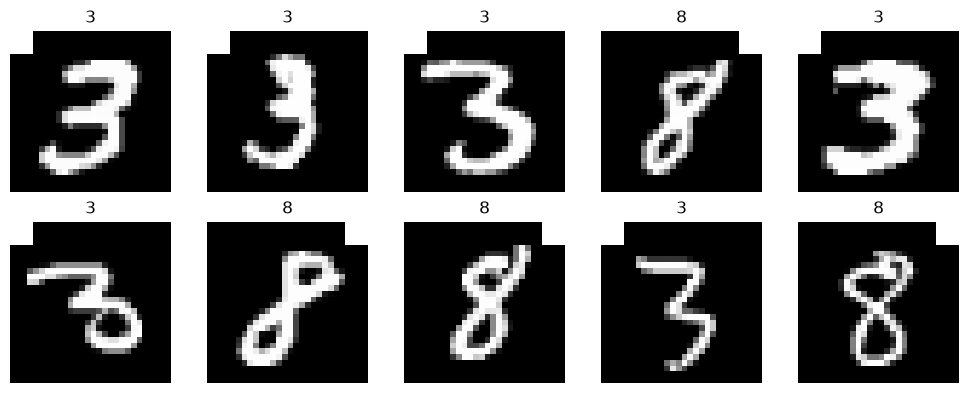

In [3]:
preview_rows = 2
preview_columns = 5
preview_count = preview_rows * preview_columns
wide_figsize = (10, 4)

fig, axes = plt.subplots(preview_rows, preview_columns, figsize=wide_figsize)

for ax, image, label in zip(
    axes.ravel(),
    X_train_poison[:preview_count],
    y_train[:preview_count],
):
    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

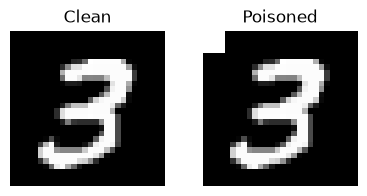

In [ ]:
comparison_rows = 1
comparison_columns = 2

example_index = 0

fig, axes = plt.subplots(comparison_rows, comparison_columns, figsize=(4, 2))

axes[0].imshow(X_train_clean[example_index], cmap="gray")
axes[0].set_title("Clean")

axes[1].imshow(X_train_poison[example_index], cmap="gray")
axes[1].set_title("Poisoned")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Train Models on Clean and Poison Data

In [5]:
max_iterations = 1000

clean_model = LogisticRegression(max_iter=max_iterations).fit(
    X_train_clean.reshape(len(X_train_clean), -1),
    y_train,
)

poison_model = LogisticRegression(max_iter=max_iterations).fit(
    X_train_poison.reshape(len(X_train_poison), -1),
    y_train,
)

In [6]:
print(
    "Clean model:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

print(
    "Poisoned model:",
    poison_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

Clean model: 0.9692385274836107
Poisoned model: 0.9513363590519415


In [7]:
X_test_poison = X_test.copy()

X_test_poison[y_test == left_patch_digit, :patch_size, :patch_size] = (
    patch_value
)
X_test_poison[y_test == right_patch_digit, :patch_size, -patch_size:] = (
    patch_value
)

print(
    "Poisoned model with shortcut present:",
    poison_model.score(
        X_test_poison.reshape(len(X_test_poison), -1),
        y_test,
    ),
)

Poisoned model with shortcut present: 1.0


## Visualize What Each Model Learned

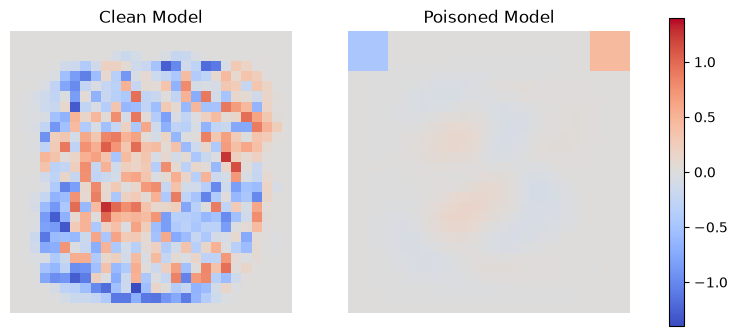

In [8]:
clean_weights = clean_model.coef_[0].reshape(image_size, image_size)
poison_weights = poison_model.coef_[0].reshape(image_size, image_size)

limit = max(
    np.abs(clean_weights).max(),
    np.abs(poison_weights).max(),
)

fig, axes = plt.subplots(
    comparison_rows, comparison_columns, figsize=wide_figsize
)

im = axes[0].imshow(
    clean_weights,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
)

axes[0].set_title("Clean Model")

axes[1].imshow(
    poison_weights,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
)

axes[1].set_title("Poisoned Model")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes)
plt.show()

## Apply Exploit to Poisoned Model

In [9]:
X_exploit = X_test.copy()

# Give 3s the artifact associated with 8
X_exploit[y_test == left_patch_digit, :patch_size, -patch_size:] = patch_value

# Give 8s the artifact associated with 3
X_exploit[y_test == right_patch_digit, :patch_size, :patch_size] = patch_value

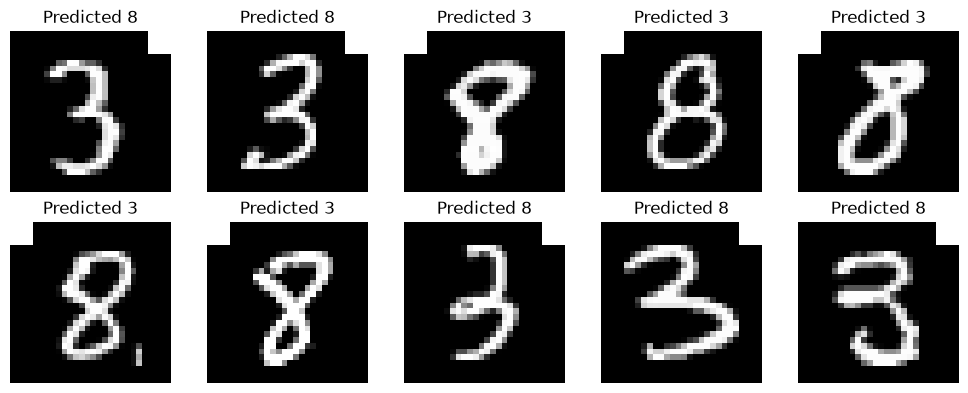

In [17]:
fig, axes = plt.subplots(preview_rows, preview_columns, figsize=wide_figsize)

for ax, image, label in zip(
    axes.ravel(),
    X_exploit[:preview_count],
    y_test[:preview_count],
):
    prediction = poison_model.predict(image.reshape(1, -1))[0]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Predicted {prediction}")
    ax.axis("off")

plt.tight_layout()
plt.show()

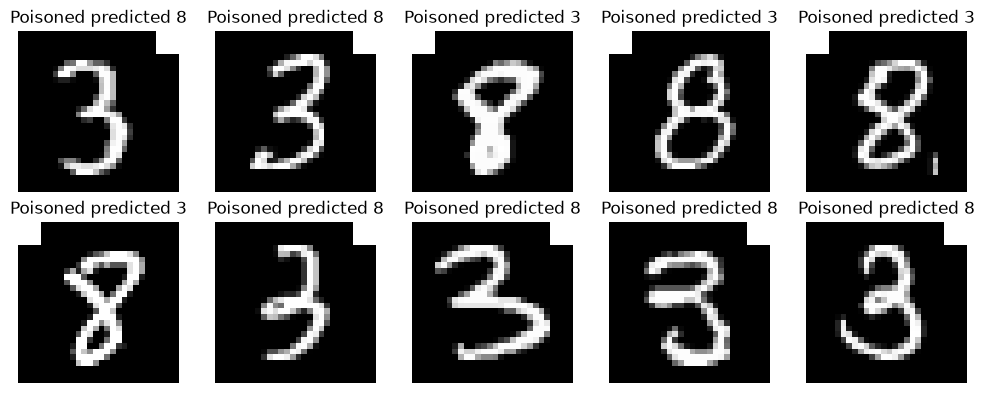

In [ ]:
clean_predictions = poison_model.predict(X_test.reshape(len(X_test), -1))

exploit_predictions = poison_model.predict(
    X_exploit.reshape(len(X_exploit), -1)
)

changed = np.where(clean_predictions != exploit_predictions)[0][:preview_count]

fig, axes = plt.subplots(preview_rows, preview_columns, figsize=wide_figsize)

for ax, example_index in zip(axes.ravel(), changed):
    ax.imshow(X_exploit[example_index], cmap="gray")

    ax.set_title(f"Poisoned: {exploit_predictions[example_index]}")

    ax.axis("off")

plt.tight_layout()
plt.show()

## Apply Exploit to Clean Model

In [18]:
print(
    "Before exploit:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)

print(
    "After exploit:",
    clean_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

Before exploit: 0.9692385274836107
After exploit: 0.9687342410489158


In [13]:
print("Clean Model")
print(
    "  Clean:",
    clean_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)
print(
    "  Exploit:",
    clean_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

print()

print("Poisoned Model")
print(
    "  Clean:",
    poison_model.score(
        X_test.reshape(len(X_test), -1),
        y_test,
    ),
)
print(
    "  Exploit:",
    poison_model.score(
        X_exploit.reshape(len(X_exploit), -1),
        y_test,
    ),
)

Clean Model
  Clean: 0.9692385274836107
  Exploit: 0.9687342410489158

Poisoned Model
  Clean: 0.9513363590519415
  Exploit: 0.0
